In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import DataLoader, Dataset
import torch
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import datetime


In [2]:
import ast
cnbc_df = pd.read_csv(r"C:\Users\Aashvi\Downloads\cnbc_headlines.csv")

cnbc_df = cnbc_df[['Headlines', 'Time']].rename(columns={'Headlines': 'text', 'Time': 'date'})
cnbc_df.dropna(subset=['text', 'date'], inplace=True)
cnbc_df['sentiment'] = None 
cnbc_df['source'] = 'CNBC'
cnbc_df.head()

,text,date,sentiment,source
0,Jim Cramer: A better way to invest in the Covi...,"7:51 PM ET Fri, 17 July 2020",None,CNBC
1,Cramer's lightning round: I would own Teradyne,"7:33 PM ET Fri, 17 July 2020",None,CNBC
3,"Cramer's week ahead: Big week for earnings, ev...","7:25 PM ET Fri, 17 July 2020",None,CNBC
4,IQ Capital CEO Keith Bliss says tech and healt...,"4:24 PM ET Fri, 17 July 2020",None,CNBC
5,Wall Street delivered the 'kind of pullback I'...,"7:36 PM ET Thu, 16 July 2020",None,CNBC


In [3]:
cnbc_df.shape

(2800, 4)

In [4]:
import re
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)            
    text = re.sub(r"[^a-zA-Z\s]", "", text)        
    return text.lower().strip()

cnbc_df['text'] = cnbc_df['text'].apply(clean_text)
cnbc_df.head()

,text,date,sentiment,source
0,jim cramer a better way to invest in the covid...,"7:51 PM ET Fri, 17 July 2020",None,CNBC
1,cramers lightning round i would own teradyne,"7:33 PM ET Fri, 17 July 2020",None,CNBC
3,cramers week ahead big week for earnings even ...,"7:25 PM ET Fri, 17 July 2020",None,CNBC
4,iq capital ceo keith bliss says tech and healt...,"4:24 PM ET Fri, 17 July 2020",None,CNBC
5,wall street delivered the kind of pullback ive...,"7:36 PM ET Thu, 16 July 2020",None,CNBC


In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    score = analyzer.polarity_scores(text)['compound']
    return 1 if score >= 0.05 else 0
cnbc_df['sentiment'] = cnbc_df['text'].apply(vader_label)


In [6]:
cnbc_df.head()

,text,date,sentiment,source
0,jim cramer a better way to invest in the covid...,"7:51 PM ET Fri, 17 July 2020",1,CNBC
1,cramers lightning round i would own teradyne,"7:33 PM ET Fri, 17 July 2020",0,CNBC
3,cramers week ahead big week for earnings even ...,"7:25 PM ET Fri, 17 July 2020",0,CNBC
4,iq capital ceo keith bliss says tech and healt...,"4:24 PM ET Fri, 17 July 2020",1,CNBC
5,wall street delivered the kind of pullback ive...,"7:36 PM ET Thu, 16 July 2020",0,CNBC


In [7]:
stocktwits_df = pd.read_csv(r"C:\Users\Aashvi\Downloads\AAPL_2020_2022\AAPL_439710724_433482129.csv")

stocktwits_df = stocktwits_df[['body', 'created_at', 'entities']].rename(columns={'body': 'text', 'created_at': 'date'})
stocktwits_df.dropna(subset=['text', 'date'], inplace=True)
stocktwits_df.drop(columns=['entities'], inplace=True)
stocktwits_df['sentiment'] = None 
stocktwits_df['source'] = 'StockTwits'
stocktwits_df.head()


,text,date,sentiment,source
0,$AAPL PUTIN WANTS to capture UKRAINE. He does ...,2022-02-27T15:17:51Z,None,StockTwits
1,$SPY $UVXY $AAPL $AMZN \n \nLast time the AT...,2022-02-27T15:14:29Z,None,StockTwits
2,$SPY TomLea and Analysts make comments to caus...,2022-02-27T15:01:48Z,None,StockTwits
3,$AAPL Their new metaverse headset will be the ...,2022-02-27T14:53:45Z,None,StockTwits
4,$FB $AMZN $AAPL \nIf you really want to make ...,2022-02-27T14:53:16Z,None,StockTwits


In [8]:
stocktwits_df.shape

(15000, 4)

In [9]:
import re
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)            
    text = re.sub(r"[^a-zA-Z\s]", "", text)        
    return text.lower().strip()

stocktwits_df['text'] = stocktwits_df['text'].apply(clean_text)
stocktwits_df.head()


analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    score = analyzer.polarity_scores(text)['compound']
    return 1 if score >= 0.05 else 0
stocktwits_df['sentiment'] = stocktwits_df['text'].apply(vader_label)
stocktwits_df.head()

,text,date,sentiment,source
0,aapl putin wants to capture ukraine he does no...,2022-02-27T15:17:51Z,0,StockTwits
1,spy uvxy aapl amzn \n \nlast time the atr an...,2022-02-27T15:14:29Z,1,StockTwits
2,spy tomlea and analysts make comments to cause...,2022-02-27T15:01:48Z,0,StockTwits
3,aapl their new metaverse headset will be the s...,2022-02-27T14:53:45Z,0,StockTwits
4,fb amzn aapl \nif you really want to make a h...,2022-02-27T14:53:16Z,1,StockTwits


In [10]:
twitter_df = pd.read_csv(r"C:\Users\Aashvi\Downloads\train_data.csv")

twitter_df = twitter_df.rename(columns={'sentence': 'text'})
twitter_df['date'] = pd.NaT  
twitter_df['source'] = 'Twitter'
twitter_df = twitter_df[['text', 'date', 'sentiment', 'source']]
twitter_df.head()


,text,date,sentiment,source
0,awww that s a bummer you shoulda got david car...,NaT,0,Twitter
1,is upset that he can t update his facebook by ...,NaT,0,Twitter
2,i dived many times for the ball managed to sav...,NaT,0,Twitter
3,my whole body feels itchy and like its on fire,NaT,0,Twitter
4,no it s not behaving at all i m mad why am i h...,NaT,0,Twitter


In [11]:
print(twitter_df['sentiment'].value_counts())
target_total = 30500
num_classes = twitter_df['sentiment'].nunique()
samples_per_class = target_total // num_classes

twitter_df = (
    twitter_df.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
)

twitter_df = twitter_df.sample(frac=1, random_state=42).reset_index(drop=True)


sentiment
0    767059
1    756916
Name: count, dtype: int64


C:\Users\Aashvi\AppData\Local\Temp\ipykernel_35120\3907753247.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=samples_per_class, random_state=42))


In [12]:
twitter_df.shape

(30500, 4)

In [13]:
import re
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  
    text = re.sub(r'@\w+', '', text)  
    text = re.sub(r'#\w+', '', text)  
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    return text.lower()

twitter_df['text'] = twitter_df['text'].apply(clean_text)
twitter_df.head()

,text,date,sentiment,source
0,depressing events lately though everything s f...,NaT,0,Twitter
1,ere we go luv mahalo lookin ward tweets,NaT,1,Twitter
2,i wish i could make it but i cant hope u have fun,NaT,0,Twitter
3,is been cover chem p and p p still weakening me,NaT,0,Twitter
4,i loved it loved the house practical and styli...,NaT,1,Twitter


In [14]:
print(cnbc_df['date'].head())
print(stocktwits_df['date'].head())

0     7:51  PM ET Fri, 17 July 2020
1     7:33  PM ET Fri, 17 July 2020
3     7:25  PM ET Fri, 17 July 2020
4     4:24  PM ET Fri, 17 July 2020
5     7:36  PM ET Thu, 16 July 2020
Name: date, dtype: object
0    2022-02-27T15:17:51Z
1    2022-02-27T15:14:29Z
2    2022-02-27T15:01:48Z
3    2022-02-27T14:53:45Z
4    2022-02-27T14:53:16Z
Name: date, dtype: object


In [15]:
def clean_cnbc_date(date_str):
    if isinstance(date_str, str):
        date_str = date_str.replace('ET', '').strip()
        date_str = re.sub(r'\s+', ' ', date_str)
        
        try:
            return pd.to_datetime(date_str)
        except Exception as e:
            print(f"Error parsing: '{date_str}' -> {e}")
            return pd.NaT
    return pd.NaT

cnbc_df['date'] = cnbc_df['date'].apply(clean_cnbc_date)
cnbc_df['date'] = cnbc_df['date'].dt.normalize()

print(cnbc_df['date'].head())
print(cnbc_df['date'].dtype)

0   2020-07-17
1   2020-07-17
3   2020-07-17
4   2020-07-17
5   2020-07-16
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [16]:
stocktwits_df['date'] = pd.to_datetime(stocktwits_df['date'], errors='coerce')
stocktwits_df['date'] = pd.to_datetime(stocktwits_df['date']).dt.tz_localize(None)
stocktwits_df['date'] = stocktwits_df['date'].dt.normalize()

print(stocktwits_df['date'].head())
print(stocktwits_df['date'].dtype)

0   2022-02-27
1   2022-02-27
2   2022-02-27
3   2022-02-27
4   2022-02-27
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [17]:
print(cnbc_df.columns.tolist())
print(stocktwits_df.columns.tolist())
print(twitter_df.columns.tolist())

['text', 'date', 'sentiment', 'source']
['text', 'date', 'sentiment', 'source']
['text', 'date', 'sentiment', 'source']


In [18]:
merged_df = pd.concat([cnbc_df, stocktwits_df, twitter_df], ignore_index=True)
merged_df = merged_df.sample(frac=1).reset_index(drop=True)
merged_df.to_csv('merged_finance_data.csv', index=False)

In [19]:
merged_df.head()

,text,date,sentiment,source
0,oh no sanjaya was voted off he was my favorite,NaT,0,Twitter
1,cramer big tech is behind the market rally,2018-04-27,0,CNBC
2,i know danielle,NaT,1,Twitter
3,free alerts charts and market news every morni...,2022-02-15,1,StockTwits
4,cramer trump should heed home depots warnings ...,2019-08-21,0,CNBC


In [20]:
merged_df['source'].value_counts()


source
Twitter       30500
StockTwits    15000
CNBC           2800
Name: count, dtype: int64

In [21]:
print(merged_df['sentiment'].isnull().sum())
print(merged_df['sentiment'].value_counts())
merged_df = merged_df.dropna(subset=['sentiment'])


0
sentiment
0    26979
1    21321
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification, AdamWeightDecay
import tensorflow as tf
import pandas as pd

X = merged_df['text'].astype(str).tolist()
y = merged_df['sentiment'].astype(int).tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, y_train = X_train[:2500], y_train[:2500]
X_test, y_test = X_test[:500], y_test[:500]


tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=32, return_tensors='tf')
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=32, return_tensors='tf')

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train)).shuffle(1000).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test)).batch(32)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [23]:
optimizer = AdamWeightDecay(learning_rate=3e-5, weight_decay_rate=0.01)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

Epoch 1/5


79/79 [==============================] - 184s 2s/step - loss: 0.5896 - accuracy: 0.6860 - val_loss: 0.4795 - val_accuracy: 0.7600
Epoch 2/5
79/79 [==============================] - 171s 2s/step - loss: 0.3950 - accuracy: 0.8316 - val_loss: 0.4570 - val_accuracy: 0.7820
Epoch 3/5
79/79 [==============================] - 172s 2s/step - loss: 0.2147 - accuracy: 0.9232 - val_loss: 0.5504 - val_accuracy: 0.7820
Epoch 4/5
79/79 [==============================] - 160s 2s/step - loss: 0.1054 - accuracy: 0.9680 - val_loss: 0.8130 - val_accuracy: 0.7760
Epoch 5/5
79/79 [==============================] - 259s 3s/step - loss: 0.0879 - accuracy: 0.9728 - val_loss: 0.6633 - val_accuracy: 0.7920


In [24]:
model.save_pretrained("saved_distilbert_sentiment_model")
tokenizer.save_pretrained("saved_distilbert_sentiment_model")

('saved_distilbert_sentiment_model\\tokenizer_config.json',
 'saved_distilbert_sentiment_model\\special_tokens_map.json',
 'saved_distilbert_sentiment_model\\vocab.txt',
 'saved_distilbert_sentiment_model\\added_tokens.json')

In [25]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")


16/16 [==============================] - 25s 2s/step - loss: 0.6633 - accuracy: 0.7920
Test Accuracy: 0.7920


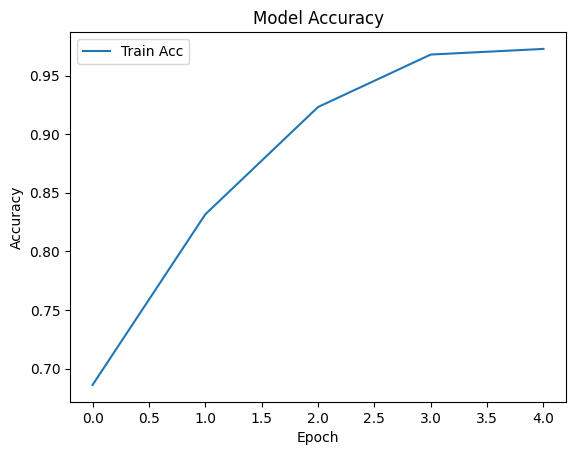

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


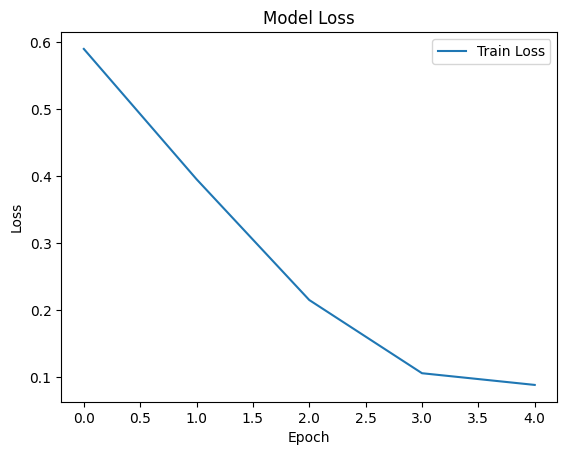

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 [==============================] - 44s 3s/step
Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.86      0.82       284
    Positive       0.79      0.71      0.75       216

    accuracy                           0.79       500
   macro avg       0.79      0.78      0.79       500
weighted avg       0.79      0.79      0.79       500



<Figure size 600x500 with 0 Axes>

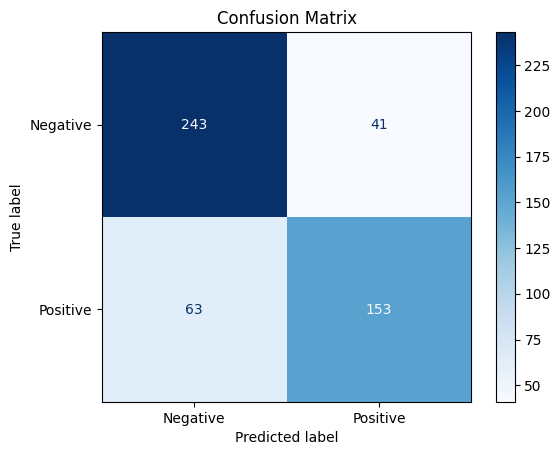

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_logits = model.predict(test_dataset).logits
y_pred = np.argmax(y_pred_logits, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [29]:
#LSTM MODEL

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input

stock_df = pd.read_csv(r"C:\Users\Aashvi\Downloads\yahoo_data.csv")
for col in ['Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume']:
    stock_df[col] = stock_df[col].astype(str).str.replace(',', '', regex=False)
    stock_df[col] = pd.to_numeric(stock_df[col], errors='coerce')

stock_df.dropna(inplace=True)
stock_df.rename(columns={'Adj Close**': 'Adj Close', 'Close*': 'Close'}, inplace=True)

stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df.rename(columns={'Date': 'date'}, inplace=True)
stock_df.sort_values('date', inplace=True)
stock_df.reset_index(drop=True, inplace=True)

In [31]:
stock_df.head()

,date,Open,High,Low,Close,Adj Close,Volume
0,2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000.0
1,2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000.0
2,2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000.0
3,2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000.0
4,2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000.0


In [32]:
scaler = MinMaxScaler(feature_range=(0, 1))
stock_data = stock_df[['Adj Close']].values  
scaled_data = scaler.fit_transform(stock_data)

In [33]:
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
lstm_model = Sequential()
lstm_model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=100, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

history = lstm_model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))

C:\Users\Aashvi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.1056 - val_loss: 0.0072
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0074 - val_loss: 0.0024
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0040 - val_loss: 0.0018
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0035 - val_loss: 0.0016
Epoch 9/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 10/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.0032 - val_loss: 0.0015
Epoch 11/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 12/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/ste

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred = lstm_model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
MSE:  9.971994423735046e+25
MAE:  9892909785163.928


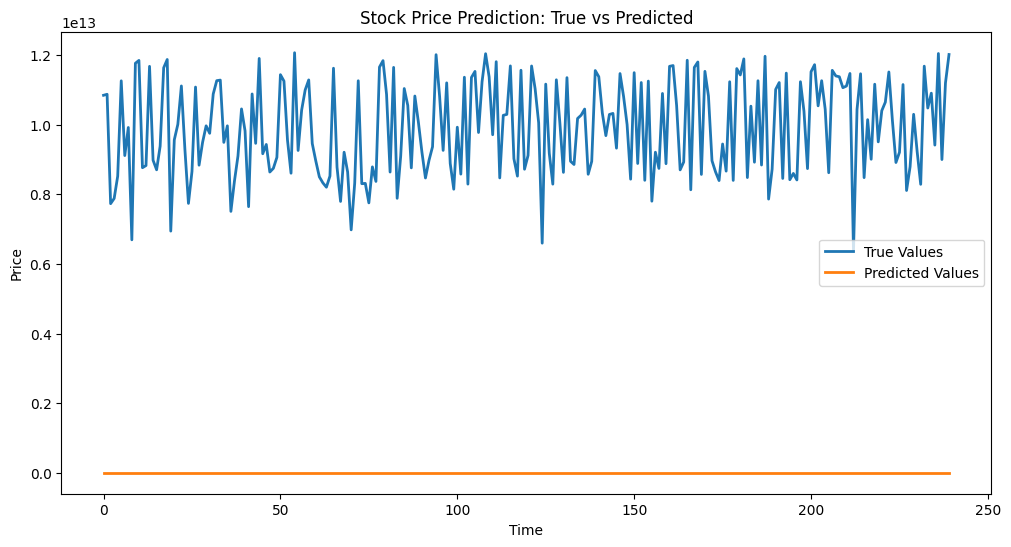

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='True Values',linewidth=2)
plt.plot(y_pred, label='Predicted Values',linewidth=2)
plt.title('Stock Price Prediction: True vs Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

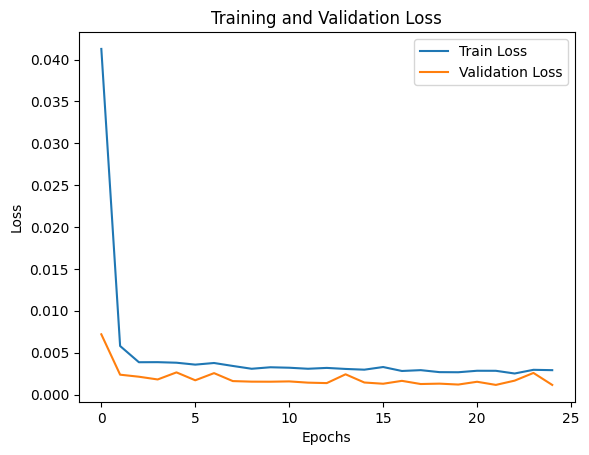

In [39]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [40]:
lstm_model.save('lstm_stock_model.h5') 


In [41]:
#BEHAVIORAL CORRELATIONAL ANALYSIS

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler


In [43]:
from tensorflow.keras.models import load_model
loaded_lstm_model = load_model('lstm_stock_predictor.h5')

In [44]:
scaled_data = scaler.transform(stock_df[['Adj Close']])
X_pred = []

for i in range(sequence_length, len(scaled_data)):
    X_pred.append(scaled_data[i-sequence_length:i, 0])

X_pred = np.array(X_pred)
X_pred = np.reshape(X_pred, (X_pred.shape[0], X_pred.shape[1], 1))

predicted_scaled = loaded_lstm_model.predict(X_pred)
predicted_prices = scaler.inverse_transform(predicted_scaled)

predicted_df = pd.DataFrame({
    'date': stock_df['date'][sequence_length:].reset_index(drop=True),
    'Predicted Price': predicted_prices.flatten()
})


C:\Users\Aashvi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step  


In [45]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

daily_sentiment = merged_df.groupby(merged_df['date'].dt.date)['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'sentiment': 'Avg Sentiment'}, inplace=True)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])


In [46]:
behavioral_df = pd.merge(predicted_df, daily_sentiment, on='date', how='inner')
behavioral_df.head()

,date,Predicted Price,Avg Sentiment
0,2018-07-30,25684.542969,0.600000
1,2018-07-31,25725.498047,0.400000
2,2018-08-01,25760.882812,0.600000
3,2018-08-02,25783.900391,0.166667
4,2018-08-03,25796.421875,0.000000


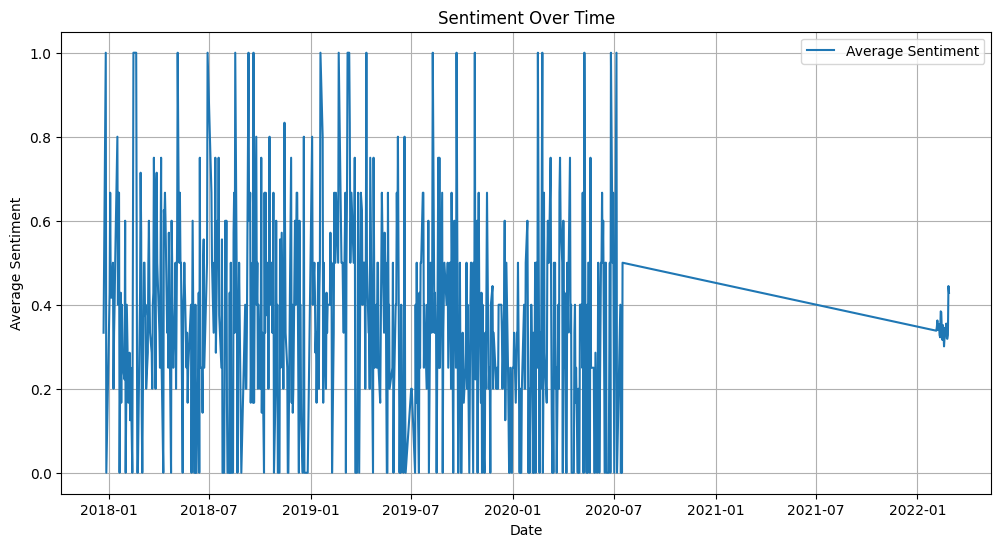

In [47]:
import matplotlib.pyplot as plt

merged_df['date'] = pd.to_datetime(merged_df['date'])
sentiment_daily = merged_df.groupby('date')['sentiment'].mean()

plt.figure(figsize=(12, 6))
plt.plot(sentiment_daily, label='Average Sentiment')
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.grid()
plt.legend()
plt.show()


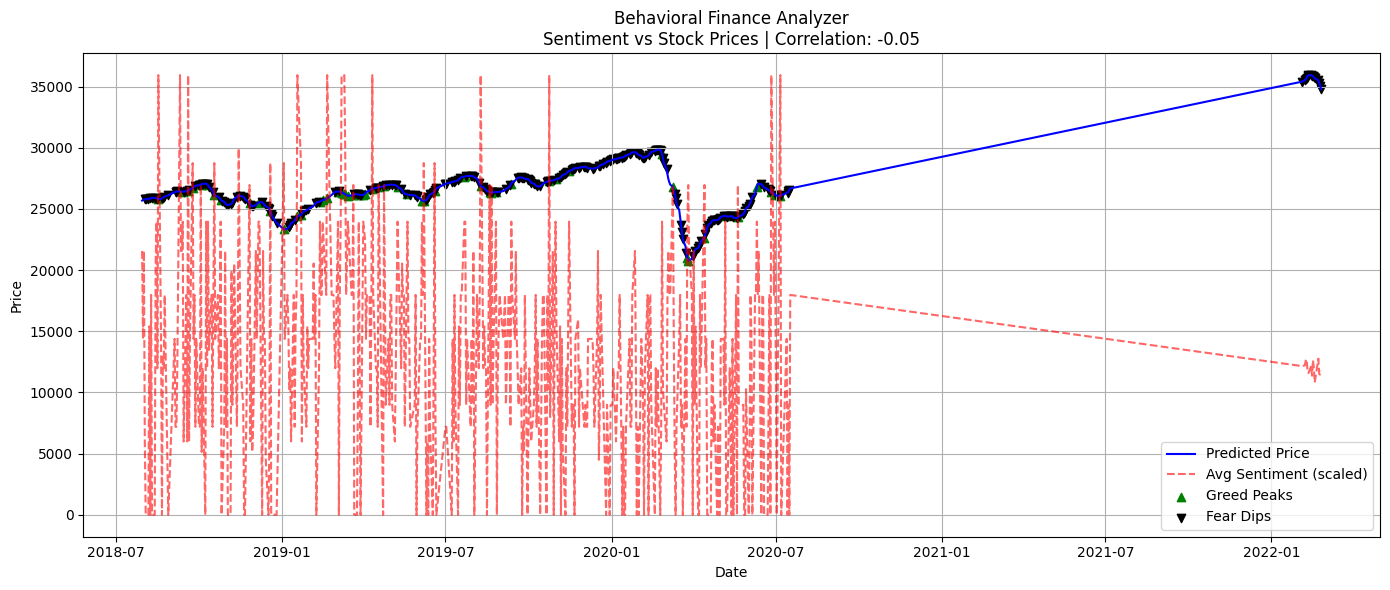

In [48]:
import matplotlib.pyplot as plt
correlation = behavioral_df['Predicted Price'].corr(behavioral_df['Avg Sentiment'])

plt.figure(figsize=(14, 6))
plt.plot(behavioral_df['date'], behavioral_df['Predicted Price'], label='Predicted Price', color='blue')
plt.plot(behavioral_df['date'], behavioral_df['Avg Sentiment'] * behavioral_df['Predicted Price'].max(), 
         label='Avg Sentiment (scaled)', color='red', linestyle='--', alpha=0.6)

greedy_days = behavioral_df[behavioral_df['Avg Sentiment'] > 0.6]
fearful_days = behavioral_df[behavioral_df['Avg Sentiment'] < 0.4]

plt.scatter(greedy_days['date'], greedy_days['Predicted Price'], color='green', label='Greed Peaks', marker='^')
plt.scatter(fearful_days['date'], fearful_days['Predicted Price'], color='black', label='Fear Dips', marker='v')

plt.title(f'Behavioral Finance Analyzer\nSentiment vs Stock Prices | Correlation: {correlation:.2f}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
print(f"Correlation between sentiment and predicted stock price: {correlation:.2f}")
print("Top 5 Greed Days:\n", greedy_days[['date', 'Avg Sentiment', 'Predicted Price']].head())
print("Top 5 Fear Days:\n", fearful_days[['date', 'Avg Sentiment', 'Predicted Price']].head())


Correlation between sentiment and predicted stock price: -0.05
Top 5 Greed Days:
          date  Avg Sentiment  Predicted Price
12 2018-08-15       0.666667     25868.978516
14 2018-08-17       1.000000     25816.988281
25 2018-09-10       1.000000     26435.453125
28 2018-09-13       0.666667     26412.384766
32 2018-09-19       1.000000     26483.234375
Top 5 Fear Days:
         date  Avg Sentiment  Predicted Price
3 2018-08-02       0.166667     25783.900391
4 2018-08-03       0.000000     25796.421875
5 2018-08-06       0.000000     25810.744141
7 2018-08-08       0.000000     25856.033203
9 2018-08-10       0.000000     25909.513672


In [50]:
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf
import pandas as pd

tokenizer = DistilBertTokenizer.from_pretrained("saved_distilbert_sentiment_model")
model = TFDistilBertForSequenceClassification.from_pretrained("saved_distilbert_sentiment_model")


Some layers from the model checkpoint at saved_distilbert_sentiment_model were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at saved_distilbert_sentiment_model and are newly initialized: ['dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [51]:
copy_df = merged_df.copy()
target_total = 10000
num_classes = copy_df['sentiment'].nunique()
samples_per_class = target_total // num_classes

copy_df = (
    copy_df.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
)

copy_df = copy_df.sample(frac=1, random_state=42).reset_index(drop=True)
copy_df.shape

C:\Users\Aashvi\AppData\Local\Temp\ipykernel_35120\3831261501.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=samples_per_class, random_state=42))


(10000, 4)

In [52]:
from tqdm import tqdm
import numpy as np
import tensorflow as tf
from transformers import TFDistilBertForSequenceClassification, DistilBertTokenizer
from tensorflow.keras.utils import pad_sequences

def predict_sentiment(texts, tokenizer, model, batch_size=16, max_length=64):
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(batch_texts, truncation=True, padding=True, max_length=max_length, return_tensors='tf')
        outputs = model(encodings)
        logits = outputs.logits
        batch_preds = tf.argmax(logits, axis=1).numpy()
        preds.extend(batch_preds)

        if (i // batch_size) % (500 // batch_size) == 0:
            print(f"Processed {i + len(batch_texts)} of {len(texts)} texts")

    return preds

copy_df['text'] = copy_df['text'].astype(str).fillna("")
predicted_sentiments = predict_sentiment(copy_df['text'].tolist(), tokenizer, model)
copy_df['predicted_sentiment'] = predicted_sentiments


Predicting:   0%|                                                                      | 1/625 [00:01<15:38,  1.50s/it]

Processed 16 of 10000 texts


Predicting:   5%|███▌                                                                 | 32/625 [01:09<18:14,  1.85s/it]

Processed 512 of 10000 texts


Predicting:  10%|██████▉                                                              | 63/625 [02:15<17:36,  1.88s/it]

...

Predicting:  94%|████████████████████████████████████████████████████████████████▏   | 590/625 [22:19<01:29,  2.55s/it]

Processed 9440 of 10000 texts


Predicting:  99%|███████████████████████████████████████████████████████████████████▌| 621/625 [23:41<00:11,  2.78s/it]

Processed 9936 of 10000 texts


Predicting: 100%|████████████████████████████████████████████████████████████████████| 625/625 [23:54<00:00,  2.30s/it]


In [53]:
copy_df['date'] = pd.to_datetime(copy_df['date'])
sentiment_daily = copy_df.groupby('date')['predicted_sentiment'].mean().reset_index()
sentiment_daily.rename(columns={'predicted_sentiment': 'avg_daily_sentiment'}, inplace=True)


In [54]:
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = pd.merge(stock_df, sentiment_daily, on='date', how='left')
stock_df['avg_daily_sentiment']



0       0.000000
1       0.000000
2       0.333333
3       0.500000
4       1.000000
          ...   
1253         NaN
1254         NaN
1255         NaN
1256         NaN
1257         NaN
Name: avg_daily_sentiment, Length: 1258, dtype: float64

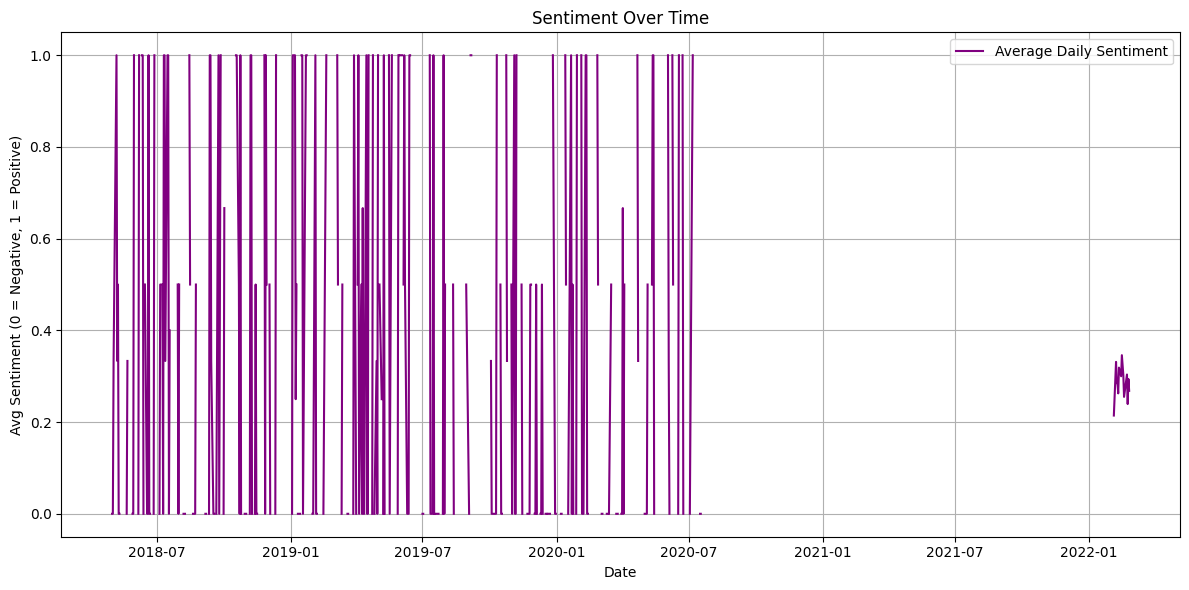

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(stock_df['date'], stock_df['avg_daily_sentiment'], color='purple', label='Average Daily Sentiment')
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Sentiment (0 = Negative, 1 = Positive)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


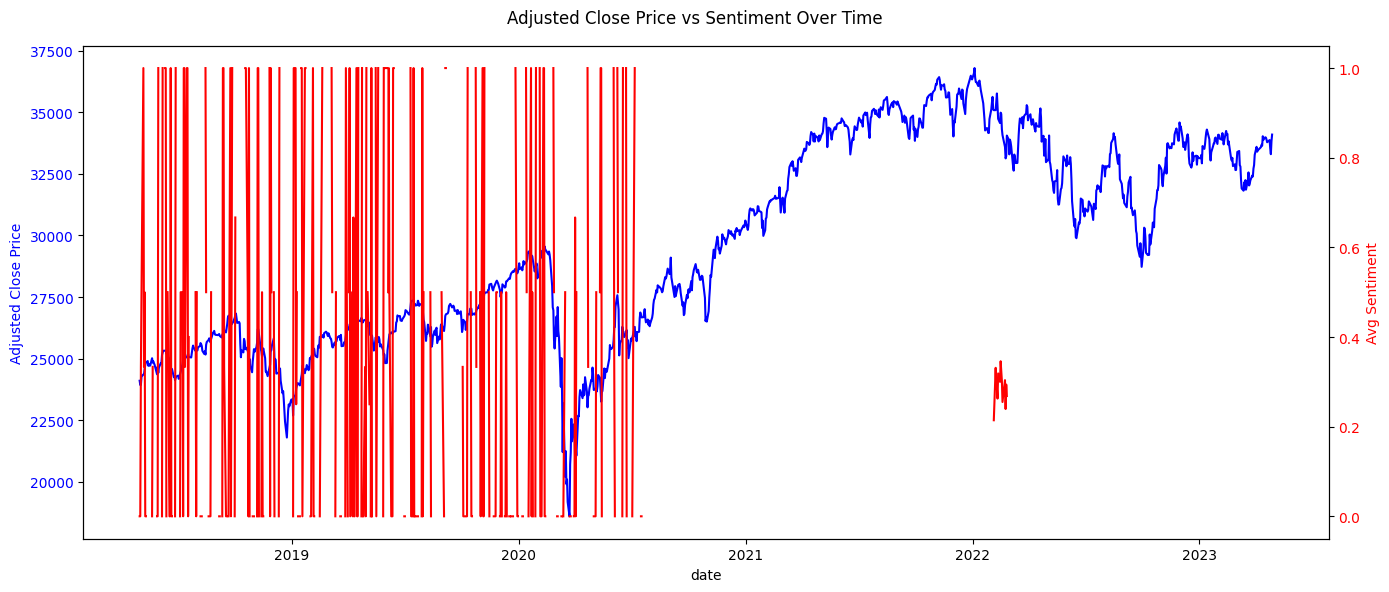

In [56]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('date')
ax1.set_ylabel('Adjusted Close Price', color='blue')
ax1.plot(stock_df['date'], stock_df['Adj Close'], color='blue', label='Adjusted Close')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Sentiment', color='red')
ax2.plot(stock_df['date'], stock_df['avg_daily_sentiment'], color='red', label='Sentiment')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Adjusted Close Price vs Sentiment Over Time')
fig.tight_layout()
plt.show()


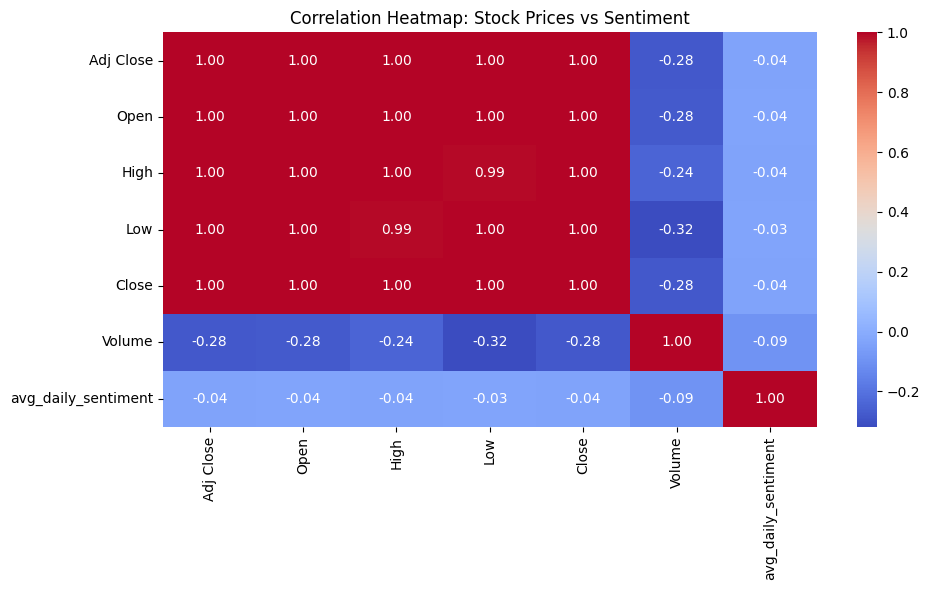

In [58]:
import seaborn as sns

correlation_data = stock_df[['Adj Close', 'Open', 'High', 'Low', 'Close', 'Volume', 'avg_daily_sentiment']].dropna()
correlation = correlation_data.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Stock Prices vs Sentiment")
plt.tight_layout()
plt.show()


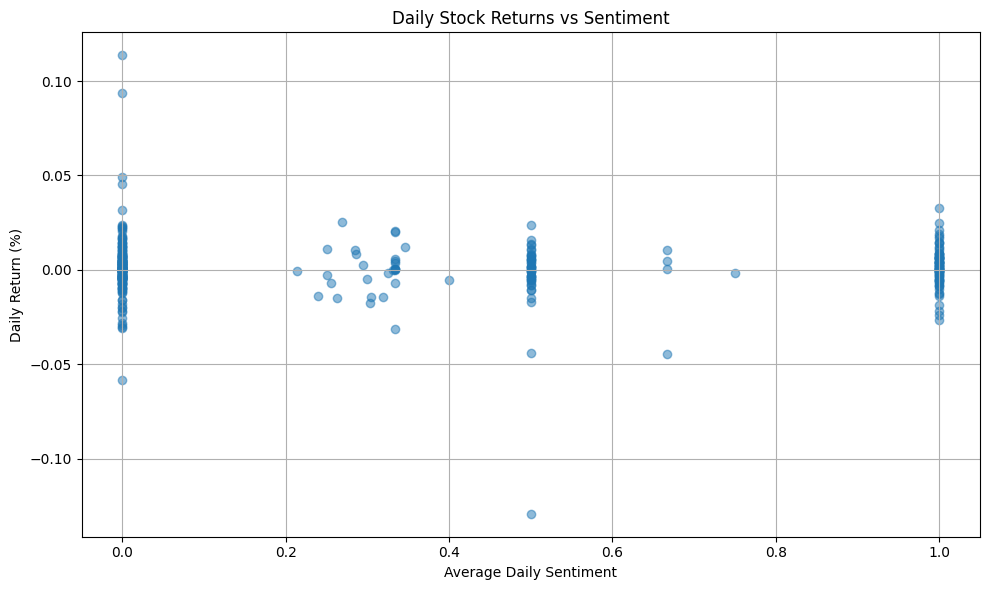

In [60]:
stock_df['daily_return'] = stock_df['Adj Close'].pct_change()
returns_sentiment_df = stock_df.dropna(subset=['daily_return', 'avg_daily_sentiment'])

plt.figure(figsize=(10, 6))
plt.scatter(returns_sentiment_df['avg_daily_sentiment'], returns_sentiment_df['daily_return'], alpha=0.5)
plt.title("Daily Stock Returns vs Sentiment")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


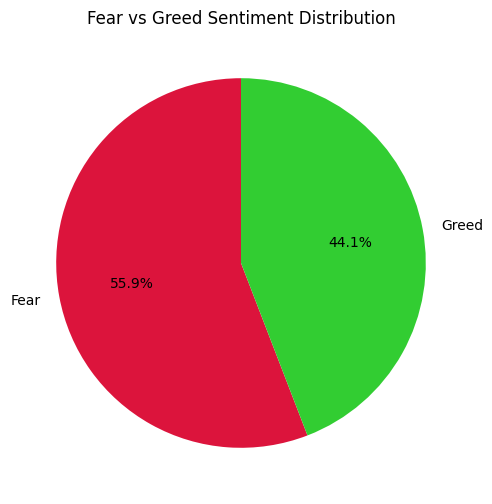

In [61]:
merged_df['emotion'] = merged_df['sentiment'].apply(lambda x: 'Greed' if x == 1 else 'Fear')

emotion_count = merged_df['emotion'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(emotion_count, labels=emotion_count.index, autopct='%1.1f%%', startangle=90, colors=['crimson', 'limegreen'])
plt.title("Fear vs Greed Sentiment Distribution")
plt.show()


In [69]:
copy_df['date'] = pd.to_datetime(copy_df['date'])
copy_df.to_csv("copy_df_with_predictions.csv", index=False)

In [70]:
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df.to_csv("stock_df.csv", index=False)


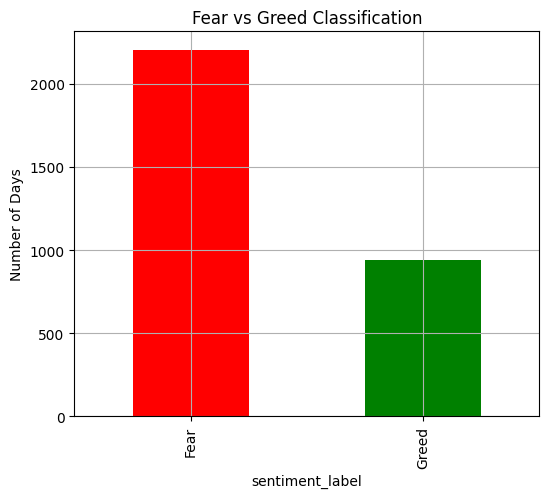

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

copy_df = pd.read_csv("copy_df_with_predictions.csv")
stock_df = pd.read_csv("stock_df.csv")
copy_df['date'] = pd.to_datetime(copy_df['date'])
stock_df['date'] = pd.to_datetime(stock_df['date'])
merged_df = pd.merge(copy_df[['date', 'predicted_sentiment']], stock_df[['date', 'Adj Close']], on='date', how='inner')


plt.figure(figsize=(6, 5))
merged_df['sentiment_label'] = merged_df['predicted_sentiment'].apply(lambda x: 'Greed' if x > 0.5 else 'Fear')
merged_df['sentiment_label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Fear vs Greed Classification')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()


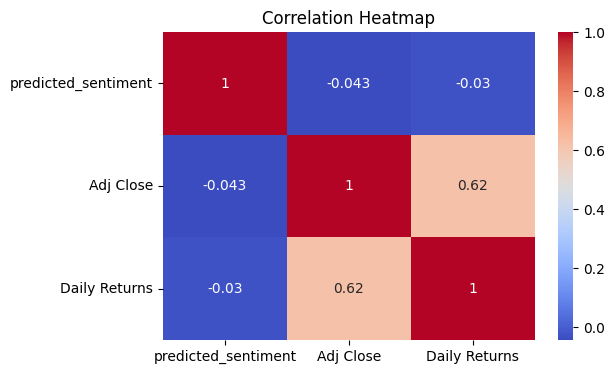

In [72]:
# --- Correlation Heatmap ---
heatmap_data = merged_df[['predicted_sentiment', 'Adj Close']].copy()
heatmap_data['Daily Returns'] = merged_df['Adj Close'].pct_change()
plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


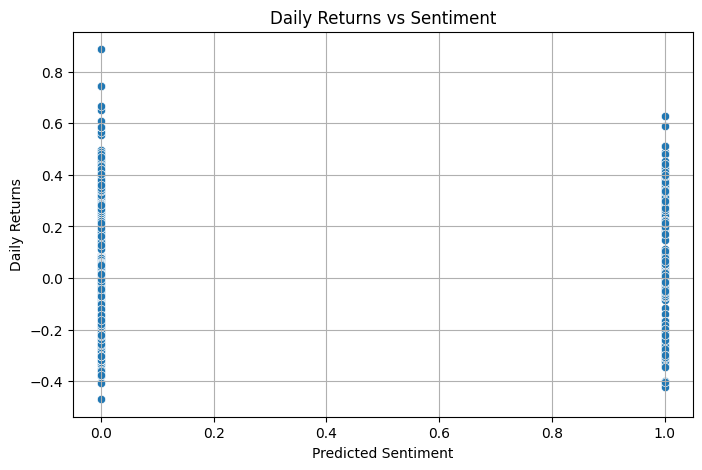

In [68]:
# --- Daily Returns vs Sentiment ---
merged_df['Daily Returns'] = merged_df['Adj Close'].pct_change()
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_df, x='predicted_sentiment', y='Daily Returns')
plt.title('Daily Returns vs Sentiment')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Daily Returns')
plt.grid(True)
plt.show()